In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazioni estetiche dei grafici
sns.set(style="whitegrid", context="talk")


In [29]:
from dotenv import load_dotenv
from pymongo import MongoClient
import os

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["biceranoPolymers"]
target="rubber_cte"

In [30]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES, Tg o densità o con SMILES malformato
df = df.dropna(subset=["smiles", target])
df = df[~df["smiles"].str.contains(r"\[\[", na=False)].copy()
df.describe()

,Tg,density,glass_cte,rubber_cte
count,314.000000,116.000000,223.000000,314.000000
mean,364.729299,1.120043,240.505115,896.207030
std,119.068992,0.200798,90.439190,287.258780
min,130.000000,0.838000,104.314790,268.200810
25%,274.250000,0.977750,172.887802,706.463013
50%,359.500000,1.084500,221.040558,853.278154
75%,419.000000,1.222500,293.769836,1067.930315
max,685.000000,1.953000,484.398992,1676.089364


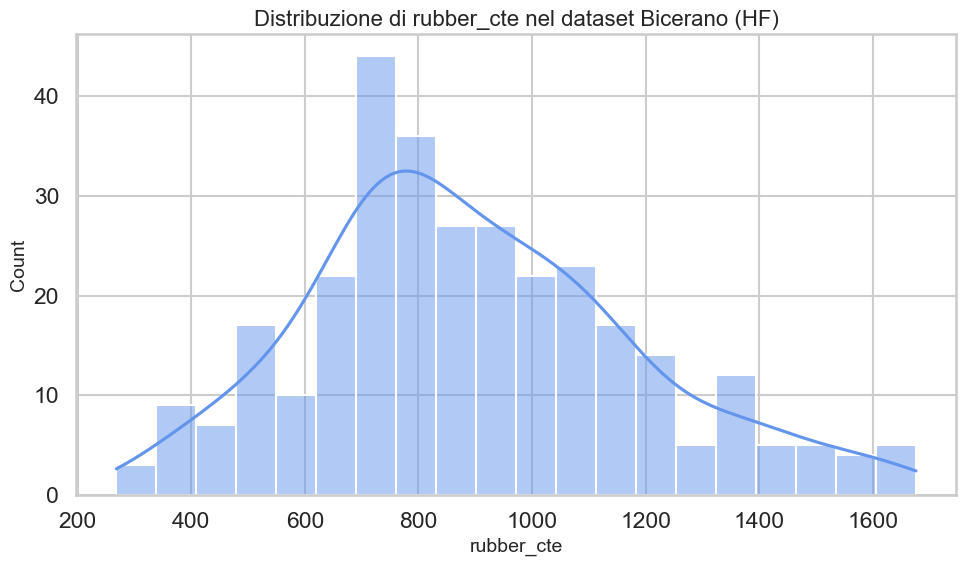

In [31]:
plt.figure(figsize=(10, 6))

# Istogramma con KDE (density plot)
sns.histplot(
    df[target],
    kde=True,
    bins=20,      # puoi adattare i bins
    color="cornflowerblue"
)

plt.xlabel(target, fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title(f"Distribuzione di {target} nel dataset Bicerano (HF)", fontsize=16)
plt.tight_layout()
plt.show()